In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma, contaminated_normal
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.stats import expon
from bayesian_dro.Bayesian_DRO_continuous import data_generation
from mis_dro.dataset import data_generation_outliers, data_generation_gamma, contaminated_normal
from bayesian_dro.Bayesian_DRO_continuous import EPSILON_SET
from mis_dro.models import univariate_GaussianModel
from mis_dro.npl import Npl
from mis_dro.dataset import *
from mis_dro.npl import *
from mis_dro.likelihood import *
from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.gaussian_kernel import *
from mis_dro.bayes_conjugates import *
from mis_dro.optimise import *

import seaborn as sns

/tmp/dcs-tmp.u1604520/ipykernel_1189791/4113369827.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [49]:
def data_generation_outliers_old(
    num_observations: int,
    contamination: float,
    random_state: Optional[np.random.Generator] = None,
):
    """A contaminated exponential data-generating process (DGP)
    Args:
        num_observations: Number of observations from DGP
        contamination: Ratio of contaminated observations (outliers)
        random_state: A numpy random generator, if provided
    Notes:
        Shuffles data to ensure anomalies are not grouped together
    """
    if not random_state:
        random_state = np.random.default_rng()
    cont_size = int(np.floor(contamination * num_observations))
    n_real = num_observations - cont_size
    data_mode1 = norm.rvs(loc=10, scale=5, size=int(n_real/2), random_state=random_state)
    data_mode2 = norm.rvs(loc=60, scale=5, size=int(n_real/2), random_state=random_state)
    outl = norm.rvs(loc=90, scale=5, size=cont_size, random_state=random_state)
    data = np.concatenate((data_mode1, data_mode2, outl), axis=0)
    random_state.shuffle(data)  # shuffles the data in-place
    return data

In [46]:
data.shape

(20, 5)

<Axes: ylabel='Density'>

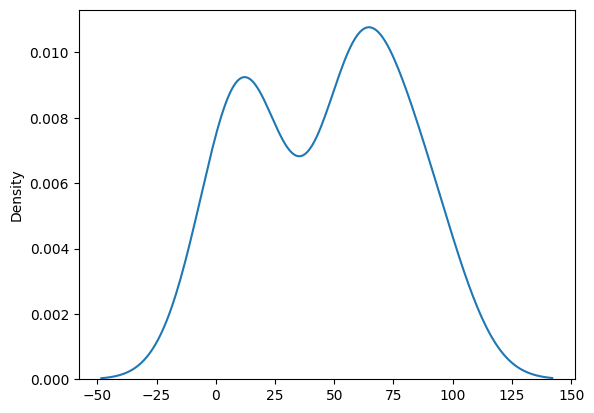

In [61]:
num_observations = 20
generator = np.random.default_rng(seed=1)
data = data_generation_outliers_old(num_observations=num_observations, contamination=0.2, random_state=generator)

sns.kdeplot(data)

In [62]:
theta_sample = sample_npl(data, inference='npl_mmd', likelihood='gaussian_known_var', num_posterior_samples=90, seed=1)

In [63]:
theta_sample

array([[60.68345637],
       [63.86521093],
       [13.10788845],
       [18.035343  ],
       [67.35907447],
       [55.93292414],
       [61.00555352],
       [78.21684296],
       [17.98367921],
       [58.14794302],
       [66.69393432],
       [15.56901959],
       [60.95600522],
       [17.73349259],
       [48.48019931],
       [17.02635499],
       [23.19079802],
       [64.99331514],
       [61.75496628],
       [15.57648372],
       [60.31752957],
       [68.66041811],
       [13.38084542],
       [56.88885126],
       [78.15161544],
       [15.87175562],
       [66.58435372],
       [16.65986434],
       [52.8669424 ],
       [15.01290458],
       [57.51869622],
       [70.86528637],
       [66.88191004],
       [56.49815491],
       [19.49505688],
       [56.35175785],
       [62.85475717],
       [69.55502075],
       [57.29076234],
       [75.92790755],
       [55.22784125],
       [59.98534067],
       [58.56985819],
       [70.43106077],
       [65.29599144],
       [74

In [64]:
# theta_sample_more = sample_npl(data, inference='npl_mmd', likelihood='exponential', num_posterior_samples=90, seed=0)

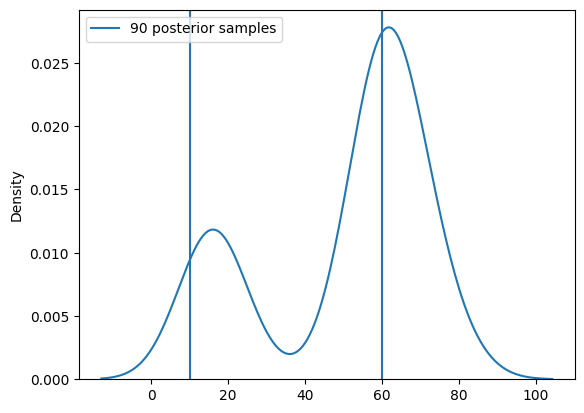

In [65]:
fig, ax = plt.subplots(nrows=1, ncols=1)
sns.kdeplot(theta_sample, ax=ax, label='90 posterior samples')
# sns.kdeplot(theta_sample_more, ax=ax, label='90 posterior samples')
ax.axvline(x=10)
ax.axvline(x=60)
plt.legend()

In [13]:
theta_sample.shape

(90, 1)

In [14]:
from mis_dro.newsvendor import *
generator = np.random.default_rng(seed=0)
likelihood = "gaussian_known_var"
dim = 1
num_likelihood_samples = 10
num_posterior_samples = 90
xi = sample_likelihood(
        likelihood,
        theta_sample,
        dim,
        num_likelihood_samples,
        generator=generator,
    )
dim_theta = 1
n_samples = 900
num_certify_points = 200
kdro_class = DRO_BAS_MMD(dim_theta, newsvendor_cost_cvxpy)
problem = kdro_class.get_problem(n_samples, num_certify_points)

In [15]:
epsilon = 0.5

In [16]:
xi = xi.reshape((num_likelihood_samples*num_posterior_samples,1))
dim_x = 1
Xcert = np.random.uniform(np.min(xi), np.max(xi), size=[num_certify_points,dim_x])
zetai = np.concatenate([xi, Xcert])
l = np.sqrt((1/2)*np.median(distance.cdist(zetai, zetai, 'sqeuclidean')))
K = k_jax(zetai, zetai, l)
K_decomp = mat_decomp_jax(K)
problem.param_dict["Xobs"].value = xi
problem.param_dict["Xcert"].value = Xcert
problem.param_dict["K"].value = np.asarray(K)
problem.param_dict["K_decomposed"].value = np.asarray(K_decomp)
problem.param_dict["epsilon"].value = np.array([epsilon])
# NOTE the MOSEK 'accept_unknown' argument is needed due to https://github.com/cvxpy/cvxpy/pull/2117
problem.solve(cp.MOSEK, verbose=False, ignore_dpp=True, accept_unknown=True)
solution = problem.var_dict["theta"].value

In [17]:
solution

array([57.59004752])

In [19]:
num_test_observations = 50
dgp = 'contaminated_exp'
# data_eval = expon.rvs(scale=10, size=num_test_observations, random_state=generator).reshape((num_test_observations,1))
data_eval = data_generation_outliers_old(num_test_observations, contamination=0.5, random_state=generator).reshape((num_test_observations,1))
out_of_sample_costs = newsvendor_cost_cvxpy(solution, data_eval).value
out_of_sample_mean = np.mean(out_of_sample_costs)
out_of_sample_var = np.var(out_of_sample_costs)

print(out_of_sample_mean, out_of_sample_var)

89.85268799535041 3557.306399141854


In [21]:
epsilon = 0.05
num_posterior_samples = 1
num_likelihood_samples = 900
problem = get_kl_bdro_problem(newsvendor_cost_cvxpy, num_posterior_samples, num_likelihood_samples, dim=dim,
    )
# posterior = 'gamma'
# theta_prior = default_prior_params(posterior, dim=dim)
# theta_posterior = get_posterior_params(posterior, data, theta_prior)
# log_partition_constant = get_log_partition_constant(posterior, theta_posterior)
# theta_sample_kl = derive_analytical_posterior_params(posterior, theta_posterior)
mu_prior, sigma_prior = 0.0, 5.0
data_mean = np.mean(data)
true_var = 5**2
mu_posterior = (true_var * mu_prior + num_observations * sigma_prior**2 * data_mean) / (
    num_observations * sigma_prior**2 + true_var
)
sigma_posterior = np.sqrt(sigma_prior**2*true_var/(true_var+num_observations*sigma_prior**2))
# theta_posterior = get_posterior_params(posterior, data_observed, theta_prior)
# theta_sample_kl = sample_posterior(posterior, theta_posterior, num_posterior_samples, generator=generator) 
theta_sample_kl = norm.rvs(
        loc=mu_posterior,
        scale=sigma_posterior,
        size=num_posterior_samples,
        random_state=generator,
        )
xi = sample_likelihood(
        likelihood,
        theta_sample_kl,
        dim,
        num_likelihood_samples,
        generator=generator,
    )
log_partition_constant = sigma_posterior/50
problem.param_dict["epsilon_minus_constant"].value = np.array([epsilon - log_partition_constant])
for i in range(num_posterior_samples):
    problem.param_dict[f"xi_{i}"].value = xi[i]
# NOTE the MOSEK 'accept_unknown' argument is needed due to https://github.com/cvxpy/cvxpy/pull/2117
problem.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True, accept_unknown=True)
solution_kl = problem.var_dict["x"].value

out_of_sample_costs_kl = newsvendor_cost_cvxpy(solution_kl, data_eval).value
out_of_sample_mean_kl = np.mean(out_of_sample_costs_kl)
out_of_sample_var_kl = np.var(out_of_sample_costs_kl)

print(solution_kl, out_of_sample_mean_kl, out_of_sample_var_kl)


[37.24529168] 136.10760966443695 3338.8680767690485
